In [1]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Union

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize


try:
    import timm
except Exception as e:
    raise RuntimeError("timm is required. Install it with: pip install timm") from e

GRADCAM_AVAILABLE = True
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except Exception:
    GRADCAM_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Grad-CAM available:", GRADCAM_AVAILABLE)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Torch: 2.6.0+cu118
CUDA available: True
Grad-CAM available: True


In [2]:
@dataclass
class Config:
    dataset_csv: str = "./cleaned_dataset.csv"
    output_dir: str = "./Output/cleaned_auxiliary"
    img_size: int = 224
    batch_size: int = 16
    epochs: int = 25
    lr: float = 3e-4
    weight_decay: float = 1e-4
    num_workers: int = 0
    seed: int = 42
    amp: bool = True                        # mixed precision (recommended on GPU)
    pin_memory: bool = True
    fully_class_boost: float = 2.0          # extra loss weight multiplier for class 'Fully'
    train_ratio: float = 0.7
    val_ratio: float = 0.2
    test_ratio: float = 0.1

CFG = Config()

LABEL_TO_CLASS = {
    0: "Bare",
    1: "Centre_Partly",    # Centre - Partly
    2: "TwoTrack_Partly",  # Two Track - Partly
    3: "OneTrack_Partly",  # One Track - Partly
    4: "Fully",
}
CLASS_NAMES = [LABEL_TO_CLASS[i] for i in sorted(LABEL_TO_CLASS)]

if "Fully" not in CLASS_NAMES:
    raise ValueError("'Fully' must exist in CLASS_NAMES to apply class weighting.")

print(f"Using label mapping: {LABEL_TO_CLASS}")

Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

Using label mapping: {0: 'Bare', 1: 'Centre_Partly', 2: 'TwoTrack_Partly', 3: 'OneTrack_Partly', 4: 'Fully'}


device(type='cuda')

In [3]:
from pathlib import PureWindowsPath

def normalize_csv_image_path(raw_path: str) -> str:
    text = str(raw_path).strip()
    if not text:
        raise ValueError("Encountered an empty image path in cleaned_dataset.csv.")

    native_path = Path(*PureWindowsPath(text).parts)
    if not native_path.is_absolute():
        native_path = Path.cwd() / native_path

    return str(native_path)

def load_cleaned_dataset(csv_path: str) -> pd.DataFrame:
    csv_file = Path(csv_path)
    if not csv_file.exists():
        raise FileNotFoundError(f"Missing CSV file: {csv_file.resolve()}")

    df = pd.read_csv(csv_file)
    if df.shape[1] < 2:
        raise ValueError("cleaned_dataset.csv must contain at least two columns: image path and label.")

    path_col, label_col = df.columns[:2]
    df = df.rename(columns={path_col: "image_path", label_col: "label"})[["image_path", "label"]].copy()

    if df["image_path"].isna().any():
        raise ValueError("Missing image_path values detected in cleaned_dataset.csv.")
    if df["label"].isna().any():
        raise ValueError("Missing label values detected in cleaned_dataset.csv.")

    df["image_path"] = df["image_path"].map(normalize_csv_image_path)
    df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

    invalid_labels = sorted(set(df["label"]) - set(LABEL_TO_CLASS))
    if invalid_labels:
        raise ValueError(f"Unexpected labels found in cleaned_dataset.csv: {invalid_labels}")

    missing_paths = [path for path in df["image_path"] if not Path(path).exists()]
    if missing_paths:
        sample = missing_paths[:5]
        raise FileNotFoundError(
            f"{len(missing_paths)} image paths from cleaned_dataset.csv do not exist. Sample: {sample}"
        )

    return df

dataset_df = load_cleaned_dataset(CFG.dataset_csv)

class_to_paths = {
    LABEL_TO_CLASS[label_idx]: dataset_df.loc[dataset_df["label"] == label_idx, "image_path"].tolist()
    for label_idx in sorted(LABEL_TO_CLASS)
}
class_counts = {class_name: len(paths) for class_name, paths in class_to_paths.items()}

counts_df = pd.DataFrame({"class": list(class_counts.keys()), "count": list(class_counts.values())})
print(f"Loaded {len(dataset_df)} rows from {Path(CFG.dataset_csv).resolve()}")
print(f"Verified image files: {sum(class_counts.values())}")
counts_df

Loaded 5360 rows from G:\GeoTrans\AuxiliaryLearning\cleaned_dataset.csv
Verified image files: 5360


,class,count
0,Bare,1890
1,Centre_Partly,705
2,TwoTrack_Partly,1864
3,OneTrack_Partly,332
4,Fully,569


In [4]:
def split_paths_per_class(paths: List[str], seed: int, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    rng = np.random.default_rng(seed)
    idx = np.arange(len(paths))
    rng.shuffle(idx)
    n = len(paths)
    n_train = int(round(n * train_ratio))
    n_val = int(round(n * val_ratio))
    n_test = n - n_train - n_val  # avoid rounding drift
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return [paths[i] for i in train_idx], [paths[i] for i in val_idx], [paths[i] for i in test_idx]

splits = {"train": [], "val": [], "test": []}  # list of (path, label_idx)
for label_idx, c in enumerate(CLASS_NAMES):
    train_p, val_p, test_p = split_paths_per_class(
        class_to_paths[c],
        CFG.seed,
        train_ratio=CFG.train_ratio,
        val_ratio=CFG.val_ratio,
        test_ratio=CFG.test_ratio,
    )
    splits["train"] += [(p, label_idx) for p in train_p]
    splits["val"]   += [(p, label_idx) for p in val_p]
    splits["test"]  += [(p, label_idx) for p in test_p]

for k in ["train", "val", "test"]:
    print(k, len(splits[k]))

def split_counts(split_list):
    arr = np.array([y for _, y in split_list])
    return {CLASS_NAMES[i]: int((arr==i).sum()) for i in range(len(CLASS_NAMES))}

print("Train counts:", split_counts(splits["train"]))
print("Val counts:", split_counts(splits["val"]))
print("Test counts:", split_counts(splits["test"]))

train 3751
val 1072
test 537
Train counts: {'Bare': 1323, 'Centre_Partly': 493, 'TwoTrack_Partly': 1305, 'OneTrack_Partly': 232, 'Fully': 398}
Val counts: {'Bare': 378, 'Centre_Partly': 141, 'TwoTrack_Partly': 373, 'OneTrack_Partly': 66, 'Fully': 114}
Test counts: {'Bare': 189, 'Centre_Partly': 71, 'TwoTrack_Partly': 186, 'OneTrack_Partly': 34, 'Fully': 57}


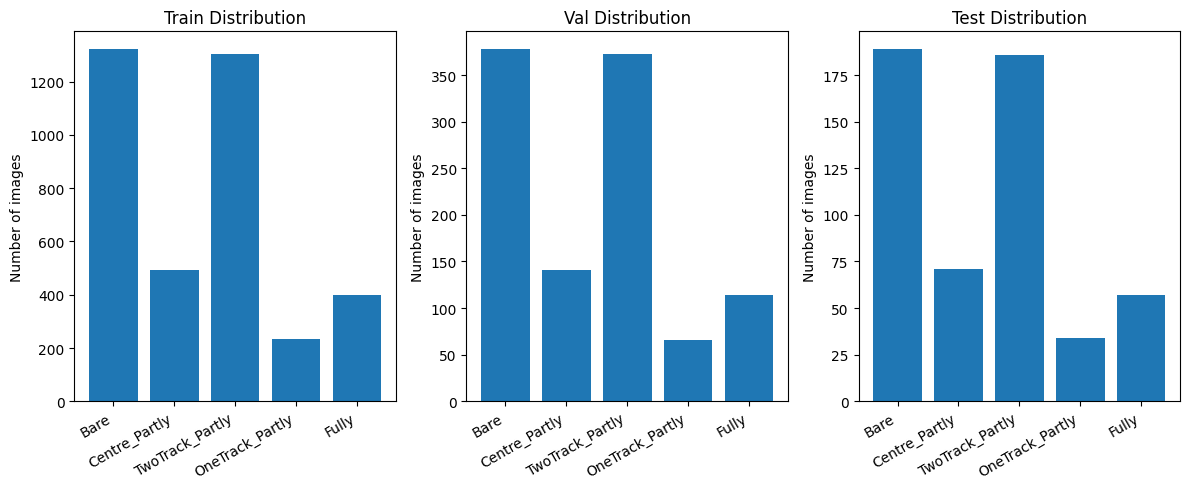

In [5]:
# Plot the train/val/test distribution
split_names = ["train", "val", "test"]
split_counts_list = [split_counts(splits[split]) for split in split_names]
plt.figure(figsize=(12, 5))
for i, split in enumerate(split_names):
    plt.subplot(1, 3, i+1)
    plt.bar(split_counts_list[i].keys(), split_counts_list[i].values())
    plt.xticks(rotation=30, ha="right")
    plt.title(f"{split.capitalize()} Distribution")
    plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

In [6]:
class RscImageDataset(Dataset):
    def __init__(self, items: List[Tuple[str, int]], transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, path

train_tf = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_tf = transforms.Compose([
    transforms.Resize((CFG.img_size, CFG.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

train_ds = RscImageDataset(splits["train"], transform=train_tf)
val_ds   = RscImageDataset(splits["val"], transform=eval_tf)
test_ds  = RscImageDataset(splits["test"], transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)
test_loader  = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=CFG.pin_memory)

len(train_loader), len(val_loader), len(test_loader)

(235, 67, 34)

In [7]:
# Visual sanity-check: show a few training samples
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

In [8]:
NUM_CLASSES = len(CLASS_NAMES)

AVAILABLE_TIMM_PRETRAINED = set(timm.list_models(pretrained=True))

MODEL_SPECS = {
    "convnext": {
        "timm_name": ["convnext_base", "convnext_base_in22k", "convnext_tiny"],
        "notes": "ConvNeXt"
    },
}

def _rank_pretrained_variant(name: str) -> Tuple[int, int]:
    score = 0

    # Prefer supervised ImageNet variants.
    if "ft_in1k" in name:
        score += 60
    if name.endswith("in1k"):
        score += 50
    if ".in1k" in name or "_in1k" in name:
        score += 30

    # Prefer lighter/default input-size variants.
    if any(tag in name for tag in ["_320", "_384", "_512"]):
        score -= 20

    # Avoid CLIP / self-supervised / multimodal checkpoints unless no alternative exists.
    if any(tag in name for tag in ["clip", "openai", "dino", "mae", "mclip", "siglip"]):
        score -= 80

    # Tie-breaker: shorter names are usually more canonical.
    return score, -len(name)

def resolve_pretrained_timm_name(name_or_list: Union[str, List[str]]) -> str:
    candidates = [name_or_list] if isinstance(name_or_list, str) else list(name_or_list)

    # 1) Exact pretrained name.
    for name in candidates:
        if name in AVAILABLE_TIMM_PRETRAINED:
            return name

    # 2) Prefix match to handle timm variant suffixes like '.fb_in1k'.
    # Keep the candidate order so model family preference is preserved.
    for name in candidates:
        matches = sorted(set(timm.list_models(f"{name}*", pretrained=True)))
        if matches:
            best = sorted(matches, key=_rank_pretrained_variant, reverse=True)[0]
            print(f"[pretrained-resolve] {name} -> {best}")
            return best

    raise ValueError(
        "No pretrained timm weights found for candidates: "
        + ", ".join(candidates)
        + ". Update MODEL_SPECS to pretrained-capable names."
    )

def create_model(model_key: str) -> Tuple[nn.Module, str]:
    spec = MODEL_SPECS[model_key]
    timm_name = resolve_pretrained_timm_name(spec["timm_name"])
    model = timm.create_model(timm_name, pretrained=True, num_classes=NUM_CLASSES)
    return model, timm_name

for k in MODEL_SPECS:
    resolved_name = resolve_pretrained_timm_name(MODEL_SPECS[k]["timm_name"])
    # Build without pretrained weights here to avoid downloading all checkpoints in this validation cell.
    m = timm.create_model(resolved_name, pretrained=False, num_classes=NUM_CLASSES)
    print(k, "=>", resolved_name, "params(M):", sum(p.numel() for p in m.parameters()) / 1e6)

[pretrained-resolve] convnext_base -> convnext_base.fb_in22k_ft_in1k
convnext => convnext_base.fb_in22k_ft_in1k params(M): 87.571589


In [9]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def get_model_output_dirs(model_key: str) -> Dict[str, Path]:
    root = Path(CFG.output_dir) / model_key
    dirs = {
        "root": root,
        "checkpoints": root / "checkpoints",
        "plots": root / "plots",
        "predictions": root / "predictions",
        "gradcam": root / "gradcam",
        "reports": root / "reports",
    }
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)
    return dirs

def save_training_curves(hist_df: pd.DataFrame, model_key: str) -> Path:
    model_dirs = get_model_output_dirs(model_key)
    out_path = model_dirs["plots"] / "training_curves.png"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
    axes[0].set_title(f"Loss Curves - {model_key}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["train_acc"], label="train_acc")
    axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    axes[1].set_title(f"Accuracy Curves - {model_key}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved training curves: {out_path}")
    return out_path

def build_class_weights(train_items: List[Tuple[str, int]]) -> torch.Tensor:
    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for _, label_idx in train_items:
        counts[label_idx] += 1

    if np.any(counts == 0):
        missing = [CLASS_NAMES[i] for i, c in enumerate(counts) if c == 0]
        raise ValueError(f"Classes with zero training samples: {missing}")

    # Inverse-frequency weighting, then boost the 'Fully' class.
    weights = counts.sum() / (NUM_CLASSES * counts.astype(np.float32))
    fully_idx = CLASS_NAMES.index("Fully")
    weights[fully_idx] *= CFG.fully_class_boost

    # Normalize for stable loss scale.
    weights = weights / weights.mean()

    print("Training class counts:", {CLASS_NAMES[i]: int(counts[i]) for i in range(NUM_CLASSES)})
    print("Loss class weights:", {CLASS_NAMES[i]: float(np.round(weights[i], 4)) for i in range(NUM_CLASSES)})

    return torch.tensor(weights, dtype=torch.float32, device=device)

CLASS_WEIGHTS = build_class_weights(splits["train"])

@torch.no_grad()
def run_eval(model, loader, criterion) -> Dict[str, float]:
    model.eval()
    all_true, all_pred = [], []
    losses = []
    for imgs, labels, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_true.append(labels.detach().cpu().numpy())
        all_pred.append(preds.detach().cpu().numpy())
    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(np.mean(losses)) if losses else float("nan")
    return metrics

def train_one_model(model_key: str):
    model_dirs = get_model_output_dirs(model_key)

    model, timm_name = create_model(model_key)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

    scaler = GradScaler(enabled=(CFG.amp and device.type == "cuda"))

    best_val_acc = -1.0
    ckpt_path = model_dirs["checkpoints"] / "best.pth"

    history = []

    for epoch in range(1, CFG.epochs + 1):
        model.train()
        epoch_losses = []
        y_true_epoch, y_pred_epoch = [], []

        pbar = tqdm(train_loader, desc=f"[{model_key}] Epoch {epoch:02d}/{CFG.epochs}", leave=False)
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda", enabled=(CFG.amp and device.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(loss.item())
            preds = torch.argmax(logits, dim=1)

            y_true_epoch.append(labels.detach().cpu().numpy())
            y_pred_epoch.append(preds.detach().cpu().numpy())

            # live metrics (approx on seen batches)
            y_true_tmp = np.concatenate(y_true_epoch)
            y_pred_tmp = np.concatenate(y_pred_epoch)
            m = compute_metrics(y_true_tmp, y_pred_tmp)
            pbar.set_postfix({"loss": float(np.mean(epoch_losses)), "acc": m["acc"], "f1": m["f1"], "recall": m["recall"]})

        # epoch train metrics
        y_true_tr = np.concatenate(y_true_epoch)
        y_pred_tr = np.concatenate(y_pred_epoch)
        train_metrics = compute_metrics(y_true_tr, y_pred_tr)
        train_metrics["loss"] = float(np.mean(epoch_losses)) if epoch_losses else float("nan")

        # val metrics
        val_metrics = run_eval(model, val_loader, criterion)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"],
        }
        history.append(row)

        print(
            f"[{model_key}] Epoch {epoch:02d} | "
            f"train loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} f1 {row['train_f1']:.4f} rec {row['train_recall']:.4f} || "
            f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.4f} f1 {row['val_f1']:.4f} rec {row['val_recall']:.4f}"
        )

        # save best by val accuracy (overwrite)
        if row["val_acc"] > best_val_acc:
            best_val_acc = row["val_acc"]
            torch.save({
                "model_key": model_key,
                "timm_name": timm_name,
                "num_classes": NUM_CLASSES,
                "class_names": CLASS_NAMES,
                "state_dict": model.state_dict(),
                "best_val_acc": best_val_acc,
                "epoch": epoch
            }, ckpt_path)
            print(f"Saved new best checkpoint to {ckpt_path} (val_acc={best_val_acc:.4f})")

    hist_df = pd.DataFrame(history)
    hist_path = model_dirs["root"] / "history.csv"
    hist_df.to_csv(hist_path, index=False)
    print(f"History saved: {hist_path}")
    save_training_curves(hist_df, model_key)

    return model, hist_df, ckpt_path

Training class counts: {'Bare': 1323, 'Centre_Partly': 493, 'TwoTrack_Partly': 1305, 'OneTrack_Partly': 232, 'Fully': 398}
Loss class weights: {'Bare': 0.2933, 'Centre_Partly': 0.7871, 'TwoTrack_Partly': 0.2973, 'OneTrack_Partly': 1.6725, 'Fully': 1.9498}


In [10]:
@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    probs_list = []
    y_true_list = []
    paths_list = []
    for imgs, labels, paths in tqdm(loader, desc="Predict", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        probs_list.append(probs)
        y_true_list.append(labels.numpy())
        paths_list += list(paths)
    probs = np.vstack(probs_list)
    y_true = np.concatenate(y_true_list)
    y_pred = np.argmax(probs, axis=1)
    pred_conf = probs[np.arange(len(y_pred)), y_pred]
    return probs, y_true, y_pred, pred_conf, paths_list

def save_confusion_matrix_image(cm: np.ndarray, title: str, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)

    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(CLASS_NAMES)

    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=10,
                fontweight="bold",
            )

    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)
    print(f"Saved confusion matrix image: {out_path}")

def save_multiclass_roc_image(y_true: np.ndarray, y_proba: np.ndarray, title: str, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)

    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 6))

    plotted = 0
    for i, cls in enumerate(CLASS_NAMES):
        positives = int(y_true_bin[:, i].sum())
        negatives = int(y_true_bin.shape[0] - positives)
        if positives == 0 or negatives == 0:
            print(f"Skipping ROC for class '{cls}' (positives={positives}, negatives={negatives}).")
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")
        plotted += 1

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    if plotted > 0:
        ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.close(fig)
    print(f"Saved ROC image: {out_path}")

def save_split_predictions_csv(model_key: str, split_name: str, paths, y_true, y_pred, y_proba, pred_conf):
    model_dirs = get_model_output_dirs(model_key)
    out_path = model_dirs["predictions"] / f"{split_name}_predictions.csv"

    df = pd.DataFrame({
        "image_path": paths,
        "actual_label": [CLASS_NAMES[i] for i in y_true],
        "predicted_label": [CLASS_NAMES[i] for i in y_pred],
        "prediction_confidence": pred_conf,
        "is_correct": (y_true == y_pred),
    })
    for j, cls in enumerate(CLASS_NAMES):
        df[f"proba_{cls}"] = y_proba[:, j]

    df.to_csv(out_path, index=False)
    print(f"Saved prediction CSV: {out_path}")
    return out_path

def save_prediction_images(paths, y_true, y_pred, pred_conf, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = 0

    for i, path in enumerate(tqdm(paths, desc=f"Prediction images -> {out_dir.name}", leave=False)):
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            print(f"Skipping prediction image for {path}: {e}")
            continue

        actual = CLASS_NAMES[int(y_true[i])]
        pred = CLASS_NAMES[int(y_pred[i])]
        conf = float(pred_conf[i])

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(img)
        ax.axis("off")
        title_color = "green" if actual == pred else "red"
        ax.set_title(
            f"Actual: {actual} | Predicted: {pred} | Confidence: {conf:.3f}",
            color=title_color,
            fontsize=10,
        )

        fname = f"{i:06d}_{Path(path).stem}_pred.jpg"
        save_path = out_dir / fname
        fig.savefig(save_path, bbox_inches="tight", dpi=160)
        plt.close(fig)
        saved += 1

    print(f"Saved {saved} prediction images to {out_dir}")

In [11]:
def denormalize(img_tensor: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    x = img_tensor.detach().cpu().numpy().transpose(1, 2, 0)
    x = (x * std) + mean
    return np.clip(x, 0, 1)

def find_last_conv2d_layer(model: nn.Module) -> nn.Module:
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    if last_conv is None:
        raise ValueError("No Conv2d layer found for Grad-CAM target layer selection.")
    return last_conv

def _reshape_transform_tokens(tensor: torch.Tensor, model: nn.Module) -> torch.Tensor:
    # ViT/Swin blocks may output [B, N, C] or [B, H, W, C].
    if tensor.ndim == 4:
        # If channels are last (BHWC), convert to BCHW.
        if tensor.shape[-1] > 16 and tensor.shape[1] <= 64 and tensor.shape[2] <= 64:
            return tensor.permute(0, 3, 1, 2)
        return tensor

    if tensor.ndim != 3:
        raise ValueError(f"Unsupported token tensor shape for Grad-CAM: {tuple(tensor.shape)}")

    b, n, c = tensor.shape

    grid = None
    patch_embed = getattr(model, "patch_embed", None)
    if patch_embed is not None and hasattr(patch_embed, "grid_size"):
        try:
            gh, gw = patch_embed.grid_size
            grid = (int(gh), int(gw))
        except Exception:
            grid = None

    if grid is not None:
        gh, gw = grid
        if n == gh * gw + 1:
            tensor = tensor[:, 1:, :]
            n = tensor.shape[1]
        elif n != gh * gw:
            grid = None

    if grid is None:
        # Fallback inference for token grids.
        if int(np.sqrt(n - 1)) ** 2 == (n - 1):
            tensor = tensor[:, 1:, :]
            n = tensor.shape[1]
        side = int(np.sqrt(n))
        if side * side != n:
            raise ValueError(f"Cannot infer spatial grid from token count n={n}.")
        gh, gw = side, side

    tensor = tensor.reshape(b, gh, gw, c)
    tensor = tensor.permute(0, 3, 1, 2)
    return tensor

def get_gradcam_components(model_key: str, model: nn.Module):
    if model_key in {"vit_base", "swin_base"}:
        if model_key == "vit_base":
            target_layer = model.blocks[-1].norm1
        else:
            target_layer = model.layers[-1].blocks[-1].norm1
        reshape_transform = lambda t: _reshape_transform_tokens(t, model)
        return target_layer, reshape_transform

    # CNN-like models: use the final Conv2d feature layer.
    target_layer = find_last_conv2d_layer(model)
    return target_layer, None

def save_gradcam_for_loader(model_key: str, model: nn.Module, loader: DataLoader, out_dir: Path, split_name: str):
    if not GRADCAM_AVAILABLE:
        print("Grad-CAM not available. Install with: pip install grad-cam")
        return

    out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()

    try:
        target_layer, reshape_transform = get_gradcam_components(model_key, model)
    except Exception as e:
        print(f"Grad-CAM target layer selection failed for {model_key}: {e}")
        return

    cam = GradCAM(model=model, target_layers=[target_layer], reshape_transform=reshape_transform)
    saved = 0

    for imgs, labels, paths in tqdm(loader, desc=f"Grad-CAM [{model_key}:{split_name}]", leave=False):
        imgs = imgs.to(device)
        for i in range(imgs.size(0)):
            img_t = imgs[i].detach().cpu()
            label = int(labels[i])
            path = paths[i]

            input_tensor = imgs[i].unsqueeze(0)
            try:
                grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
            except Exception as e:
                print(f"Grad-CAM failed for {path}: {e}")
                continue

            rgb = denormalize(img_t)
            cam_img = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

            fname = f"{saved:06d}_{Path(path).stem}_cam.jpg"
            save_path = out_dir / CLASS_NAMES[label] / fname
            save_path.parent.mkdir(parents=True, exist_ok=True)
            Image.fromarray(cam_img).save(save_path)
            saved += 1

    print(f"Saved {saved} Grad-CAM images to {out_dir}")

In [12]:
def evaluate_model_on_split(model_key: str, model: nn.Module, loader: DataLoader, split_name: str) -> Dict[str, float]:
    y_proba, y_true, y_pred, pred_conf, paths = predict_proba(model, loader)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"[{model_key}][{split_name}] Acc={acc:.4f} | F1(macro)={f1:.4f} | Recall(macro)={rec:.4f}")

    model_dirs = get_model_output_dirs(model_key)

    report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
    report_path = model_dirs["reports"] / f"{split_name}_classification_report.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_text)
    print(f"Saved classification report: {report_path}")

    save_split_predictions_csv(model_key, split_name, paths, y_true, y_pred, y_proba, pred_conf)
    save_prediction_images(paths, y_true, y_pred, pred_conf, model_dirs["predictions"] / split_name)

    cm = confusion_matrix(y_true, y_pred)
    save_confusion_matrix_image(
        cm,
        title=f"Confusion Matrix ({split_name}) - {model_key}",
        out_path=model_dirs["plots"] / f"{split_name}_confusion_matrix.png",
    )

    save_multiclass_roc_image(
        y_true,
        y_proba,
        title=f"ROC Curves ({split_name}) - {model_key}",
        out_path=model_dirs["plots"] / f"{split_name}_roc_curve.png",
    )

    save_gradcam_for_loader(
        model_key,
        model,
        loader,
        out_dir=model_dirs["gradcam"] / split_name,
        split_name=split_name,
    )

    return {
        f"{split_name}_acc": acc,
        f"{split_name}_f1_macro": f1,
        f"{split_name}_recall_macro": rec,
    }

In [13]:
def evaluate_model_artifacts(model_key: str, model: nn.Module, ckpt_path: Path) -> Dict[str, Union[str, float]]:
    print()
    print("-" * 80)
    print(f"EVALUATING: {model_key} | {MODEL_SPECS[model_key]['notes']}")
    print("-" * 80)

    val_metrics = evaluate_model_on_split(model_key, model, val_loader, split_name="val")
    test_metrics = evaluate_model_on_split(model_key, model, test_loader, split_name="test")

    result = {
        "model_key": model_key,
        "best_ckpt": str(ckpt_path),
    }
    result.update(val_metrics)
    result.update(test_metrics)
    return result

def upsert_summary(results_list: List[Dict[str, Union[str, float]]], result: Dict[str, Union[str, float]]):
    for i, row in enumerate(results_list):
        if row["model_key"] == result["model_key"]:
            results_list[i] = result
            return
    results_list.append(result)

In [15]:
# -----------------------------------------------------------------------------
# Auxiliary learning with VLM context (JSON -> text features -> ConvNeXt fusion)
# -----------------------------------------------------------------------------
import json
from collections import Counter
from typing import Any, Optional

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

import torch.nn.functional as F

AUX_MODEL_KEY = "convnext_aux_context"
CONTEXT_JSON_PATH = Path("./gemini_road_context.json")
CONTEXT_IGNORE_FIELDS = {"id", "Image_name", "Class", "VLM_Raw_Output"}
CONTEXT_MAX_TFIDF_FEATURES = 4000
CONTEXT_NGRAM_RANGE = (1, 2)
CONTEXT_SVD_DIM = 128
CONTEXT_ALIGN_LOSS_WEIGHT = 0.15


def normalize_image_name(name: str) -> str:
    return Path(str(name)).name.lower().strip()


def row_to_context_text(row: Dict[str, Any]) -> str:
    chunks = []
    for key, value in row.items():
        if key in CONTEXT_IGNORE_FIELDS:
            continue
        if value is None:
            continue
        text = str(value).strip()
        if not text:
            continue
        chunks.append(f"{key}: {text}")
    return " | ".join(chunks)


def load_context_lookup(json_path: Path) -> Dict[str, Dict[str, str]]:
    if not json_path.exists():
        raise FileNotFoundError(f"Context JSON not found: {json_path.resolve()}")

    rows = json.loads(json_path.read_text(encoding="utf-8"))
    if not isinstance(rows, list):
        raise ValueError("Context JSON must be a list of records.")

    lookup: Dict[str, Dict[str, str]] = {}
    duplicate_keys = []
    for row in rows:
        image_name = str(row.get("Image_name", "")).strip()
        if not image_name:
            continue

        key = normalize_image_name(image_name)
        if key in lookup:
            duplicate_keys.append(key)

        lookup[key] = {
            "class_name": str(row.get("Class", "")).strip(),
            "context_text": row_to_context_text(row),
        }

    if duplicate_keys:
        print(f"[context] Warning: {len(duplicate_keys)} duplicate Image_name keys found in JSON.")

    return lookup


def split_context_coverage(split_items: List[Tuple[str, int]], lookup: Dict[str, Dict[str, str]]) -> Dict[str, int]:
    available = 0
    for path, _ in split_items:
        key = normalize_image_name(path)
        if key in lookup and lookup[key].get("context_text", "").strip():
            available += 1
    total = len(split_items)
    return {"available": available, "missing": total - available, "total": total}


CONTEXT_LOOKUP = load_context_lookup(CONTEXT_JSON_PATH)

all_split_items = splits["train"] + splits["val"] + splits["test"]
name_to_dataset_class = {normalize_image_name(p): CLASS_NAMES[label_idx] for p, label_idx in all_split_items}

context_class_mismatch = 0
for key, payload in CONTEXT_LOOKUP.items():
    if key not in name_to_dataset_class:
        continue
    json_class = payload.get("class_name", "")
    dataset_class = name_to_dataset_class[key]
    if json_class and json_class != dataset_class:
        context_class_mismatch += 1

print(f"[context] Loaded JSON records: {len(CONTEXT_LOOKUP)}")
print(f"[context] Class mismatches vs dataset folder labels: {context_class_mismatch}")

for split_name in ["train", "val", "test"]:
    cov = split_context_coverage(splits[split_name], CONTEXT_LOOKUP)
    pct = (100.0 * cov["available"] / max(cov["total"], 1))
    print(
        f"[context][{split_name}] available={cov['available']} "
        f"missing={cov['missing']} total={cov['total']} ({pct:.2f}% with context)"
    )


[context] Loaded JSON records: 7615
[context] Class mismatches vs dataset folder labels: 0
[context][train] available=3751 missing=0 total=3751 (100.00% with context)
[context][val] available=1072 missing=0 total=1072 (100.00% with context)
[context][test] available=537 missing=0 total=537 (100.00% with context)


In [16]:
def get_context_text_and_mask(image_path: str) -> Tuple[str, float]:
    payload = CONTEXT_LOOKUP.get(normalize_image_name(image_path))
    if payload is None:
        return "", 0.0
    context_text = payload.get("context_text", "").strip()
    return context_text, float(bool(context_text))


def collect_split_context(split_items: List[Tuple[str, int]]) -> Tuple[List[str], np.ndarray]:
    texts: List[str] = []
    masks: List[float] = []
    for path, _ in split_items:
        txt, m = get_context_text_and_mask(path)
        texts.append(txt)
        masks.append(m)
    return texts, np.asarray(masks, dtype=np.float32)


train_context_texts, train_context_masks = collect_split_context(splits["train"])
val_context_texts, val_context_masks = collect_split_context(splits["val"])
test_context_texts, test_context_masks = collect_split_context(splits["test"])

if int((train_context_masks > 0).sum()) == 0:
    raise ValueError("No non-empty context text found in training split. Cannot build text features.")

context_vectorizer = TfidfVectorizer(
    max_features=CONTEXT_MAX_TFIDF_FEATURES,
    ngram_range=CONTEXT_NGRAM_RANGE,
    lowercase=True,
    strip_accents="unicode",
)

train_context_sparse = context_vectorizer.fit_transform(train_context_texts)
max_rank = int(min(train_context_sparse.shape[0] - 1, train_context_sparse.shape[1] - 1))

if max_rank >= 2:
    context_components = int(min(CONTEXT_SVD_DIM, max_rank))
    context_reducer = make_pipeline(
        TruncatedSVD(n_components=context_components, random_state=CFG.seed),
        Normalizer(copy=False),
    )
    train_context_features = context_reducer.fit_transform(train_context_sparse).astype(np.float32)
else:
    context_reducer = None
    train_context_features = train_context_sparse.toarray().astype(np.float32)


def transform_context_texts(texts: List[str]) -> np.ndarray:
    sparse = context_vectorizer.transform(texts)
    if context_reducer is not None:
        dense = context_reducer.transform(sparse)
    else:
        dense = sparse.toarray()
    return dense.astype(np.float32)


val_context_features = transform_context_texts(val_context_texts)
test_context_features = transform_context_texts(test_context_texts)

CONTEXT_FEATURE_DIM = int(train_context_features.shape[1])
print(f"[context] TF-IDF vocabulary size: {len(context_vectorizer.vocabulary_)}")
print(f"[context] Context feature dimension after reduction: {CONTEXT_FEATURE_DIM}")


def build_context_feature_map(
    split_items: List[Tuple[str, int]],
    features: np.ndarray,
    masks: np.ndarray,
) -> Dict[str, Tuple[np.ndarray, float]]:
    output: Dict[str, Tuple[np.ndarray, float]] = {}
    for (path, _), feature_vec, mask in zip(split_items, features, masks):
        output[path] = (feature_vec.astype(np.float32), float(mask))
    return output


train_context_feature_map = build_context_feature_map(splits["train"], train_context_features, train_context_masks)
val_context_feature_map = build_context_feature_map(splits["val"], val_context_features, val_context_masks)
test_context_feature_map = build_context_feature_map(splits["test"], test_context_features, test_context_masks)

[context] TF-IDF vocabulary size: 4000
[context] Context feature dimension after reduction: 128


In [17]:
class RscImageContextDataset(Dataset):
    def __init__(
        self,
        items: List[Tuple[str, int]],
        context_feature_map: Dict[str, Tuple[np.ndarray, float]],
        context_dim: int,
        transform=None,
    ):
        self.items = items
        self.context_feature_map = context_feature_map
        self.context_dim = context_dim
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        context_feature, context_mask = self.context_feature_map.get(path, (None, 0.0))
        if context_feature is None:
            context_feature = np.zeros(self.context_dim, dtype=np.float32)

        context_tensor = torch.tensor(context_feature, dtype=torch.float32)
        mask_tensor = torch.tensor(context_mask, dtype=torch.float32)

        return img, label, path, context_tensor, mask_tensor


aux_train_ds = RscImageContextDataset(
    splits["train"],
    train_context_feature_map,
    context_dim=CONTEXT_FEATURE_DIM,
    transform=train_tf,
)
aux_val_ds = RscImageContextDataset(
    splits["val"],
    val_context_feature_map,
    context_dim=CONTEXT_FEATURE_DIM,
    transform=eval_tf,
)
aux_test_ds = RscImageContextDataset(
    splits["test"],
    test_context_feature_map,
    context_dim=CONTEXT_FEATURE_DIM,
    transform=eval_tf,
)

aux_train_loader = DataLoader(
    aux_train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
)
aux_val_loader = DataLoader(
    aux_val_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
)
aux_test_loader = DataLoader(
    aux_test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
)

print(
    "[context] Auxiliary loaders:",
    len(aux_train_loader), len(aux_val_loader), len(aux_test_loader),
)



[context] Auxiliary loaders: 235 67 34


In [18]:
class ConvNeXtContextAuxModel(nn.Module):
    def __init__(
        self,
        timm_name: str,
        num_classes: int,
        context_dim: int,
        fusion_hidden_dim: int = 512,
        align_dim: int = 256,
        dropout_p: float = 0.2,
    ):
        super().__init__()
        self.context_dim = int(context_dim)

        self.image_backbone = timm.create_model(
            timm_name,
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        image_feat_dim = int(self.image_backbone.num_features)

        self.context_encoder = nn.Sequential(
            nn.LayerNorm(self.context_dim),
            nn.Linear(self.context_dim, fusion_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(fusion_hidden_dim, fusion_hidden_dim),
            nn.GELU(),
        )

        self.image_align_head = nn.Sequential(
            nn.Linear(image_feat_dim, align_dim),
            nn.GELU(),
            nn.Linear(align_dim, align_dim),
        )
        self.context_align_head = nn.Sequential(
            nn.Linear(fusion_hidden_dim, align_dim),
            nn.GELU(),
            nn.Linear(align_dim, align_dim),
        )

        self.missing_context_embedding = nn.Parameter(torch.zeros(fusion_hidden_dim))

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + fusion_hidden_dim, fusion_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(fusion_hidden_dim, num_classes),
        )

    def _encode_image(self, imgs: torch.Tensor) -> torch.Tensor:
        image_feat = self.image_backbone(imgs)
        if isinstance(image_feat, (list, tuple)):
            image_feat = image_feat[-1]
        if image_feat.ndim > 2:
            image_feat = torch.flatten(F.adaptive_avg_pool2d(image_feat, 1), 1)
        return image_feat

    def forward(
        self,
        imgs: torch.Tensor,
        context_vec: Optional[torch.Tensor] = None,
        context_mask: Optional[torch.Tensor] = None,
        return_aux: bool = False,
    ):
        image_feat = self._encode_image(imgs)
        batch_size = image_feat.size(0)

        if context_vec is None:
            context_vec = torch.zeros(
                (batch_size, self.context_dim),
                device=image_feat.device,
                dtype=image_feat.dtype,
            )
        else:
            context_vec = context_vec.to(device=image_feat.device, dtype=image_feat.dtype)

        if context_mask is None:
            context_mask = torch.zeros(batch_size, device=image_feat.device, dtype=image_feat.dtype)
        else:
            context_mask = context_mask.to(device=image_feat.device, dtype=image_feat.dtype).view(-1)

        context_feat = self.context_encoder(context_vec)
        mask_2d = context_mask.unsqueeze(1)
        context_feat = (
            context_feat * mask_2d
            + self.missing_context_embedding.unsqueeze(0) * (1.0 - mask_2d)
        )

        fused_feat = torch.cat([image_feat, context_feat], dim=1)
        logits = self.classifier(fused_feat)

        if not return_aux:
            return logits

        valid = context_mask > 0.5
        if bool(valid.any()):
            img_emb = F.normalize(self.image_align_head(image_feat[valid]), dim=1)
            ctx_emb = F.normalize(self.context_align_head(context_feat[valid]), dim=1)
            align_loss = 1.0 - (img_emb * ctx_emb).sum(dim=1).mean()
        else:
            align_loss = torch.tensor(0.0, device=image_feat.device, dtype=image_feat.dtype)

        aux = {
            "align_loss": align_loss,
            "context_ratio": context_mask.mean().detach(),
        }
        return logits, aux


def create_aux_convnext_model() -> Tuple[nn.Module, str]:
    timm_name = resolve_pretrained_timm_name(MODEL_SPECS["convnext"]["timm_name"])
    model = ConvNeXtContextAuxModel(
        timm_name=timm_name,
        num_classes=NUM_CLASSES,
        context_dim=CONTEXT_FEATURE_DIM,
    )
    return model, timm_name


@torch.no_grad()
def run_eval_aux(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> Dict[str, float]:
    model.eval()
    all_true, all_pred = [], []
    losses, align_losses = [], []

    for imgs, labels, _, context_vec, context_mask in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        context_vec = context_vec.to(device, non_blocking=True)
        context_mask = context_mask.to(device, non_blocking=True)

        logits, aux = model(imgs, context_vec, context_mask, return_aux=True)
        cls_loss = criterion(logits, labels)
        align_loss = aux["align_loss"]
        loss = cls_loss + (CONTEXT_ALIGN_LOSS_WEIGHT * align_loss)

        losses.append(float(loss.item()))
        align_losses.append(float(align_loss.item()))

        preds = torch.argmax(logits, dim=1)
        all_true.append(labels.detach().cpu().numpy())
        all_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(np.mean(losses)) if losses else float("nan")
    metrics["align_loss"] = float(np.mean(align_losses)) if align_losses else 0.0
    return metrics


def train_aux_convnext_model(model_key: str = AUX_MODEL_KEY):
    model_dirs = get_model_output_dirs(model_key)

    model, timm_name = create_aux_convnext_model()
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scaler = GradScaler(enabled=(CFG.amp and device.type == "cuda"))

    best_val_acc = -1.0
    ckpt_path = model_dirs["checkpoints"] / "best.pth"
    history = []

    for epoch in range(1, CFG.epochs + 1):
        model.train()
        epoch_losses, epoch_align_losses = [], []
        y_true_epoch, y_pred_epoch = [], []

        pbar = tqdm(aux_train_loader, desc=f"[{model_key}] Epoch {epoch:02d}/{CFG.epochs}", leave=False)
        for imgs, labels, _, context_vec, context_mask in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            context_vec = context_vec.to(device, non_blocking=True)
            context_mask = context_mask.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda", enabled=(CFG.amp and device.type == "cuda")):
                logits, aux = model(imgs, context_vec, context_mask, return_aux=True)
                cls_loss = criterion(logits, labels)
                align_loss = aux["align_loss"]
                loss = cls_loss + (CONTEXT_ALIGN_LOSS_WEIGHT * align_loss)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(float(loss.item()))
            epoch_align_losses.append(float(align_loss.detach().cpu().item()))

            preds = torch.argmax(logits, dim=1)
            y_true_epoch.append(labels.detach().cpu().numpy())
            y_pred_epoch.append(preds.detach().cpu().numpy())

            y_true_tmp = np.concatenate(y_true_epoch)
            y_pred_tmp = np.concatenate(y_pred_epoch)
            m = compute_metrics(y_true_tmp, y_pred_tmp)
            pbar.set_postfix({
                "loss": float(np.mean(epoch_losses)),
                "align": float(np.mean(epoch_align_losses)),
                "acc": m["acc"],
                "f1": m["f1"],
            })

        y_true_tr = np.concatenate(y_true_epoch)
        y_pred_tr = np.concatenate(y_pred_epoch)
        train_metrics = compute_metrics(y_true_tr, y_pred_tr)
        train_metrics["loss"] = float(np.mean(epoch_losses)) if epoch_losses else float("nan")
        train_metrics["align_loss"] = float(np.mean(epoch_align_losses)) if epoch_align_losses else 0.0

        val_metrics = run_eval_aux(model, aux_val_loader, criterion)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "train_align_loss": train_metrics["align_loss"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"],
            "val_align_loss": val_metrics["align_loss"],
        }
        history.append(row)

        print(
            f"[{model_key}] Epoch {epoch:02d} | "
            f"train loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} f1 {row['train_f1']:.4f} "
            f"align {row['train_align_loss']:.4f} || "
            f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.4f} f1 {row['val_f1']:.4f} "
            f"align {row['val_align_loss']:.4f}"
        )

        if row["val_acc"] > best_val_acc:
            best_val_acc = row["val_acc"]
            torch.save(
                {
                    "model_key": model_key,
                    "timm_name": timm_name,
                    "num_classes": NUM_CLASSES,
                    "class_names": CLASS_NAMES,
                    "context_feature_dim": CONTEXT_FEATURE_DIM,
                    "context_align_loss_weight": CONTEXT_ALIGN_LOSS_WEIGHT,
                    "state_dict": model.state_dict(),
                    "best_val_acc": best_val_acc,
                    "epoch": epoch,
                },
                ckpt_path,
            )
            print(f"Saved new best checkpoint to {ckpt_path} (val_acc={best_val_acc:.4f})")

    hist_df = pd.DataFrame(history)
    hist_path = model_dirs["root"] / "history.csv"
    hist_df.to_csv(hist_path, index=False)
    print(f"History saved: {hist_path}")

    save_training_curves(hist_df, model_key)

    # Optional: alignment loss curve for the auxiliary term.
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(hist_df["epoch"], hist_df["train_align_loss"], label="train_align_loss")
    ax.plot(hist_df["epoch"], hist_df["val_align_loss"], label="val_align_loss")
    ax.set_title(f"Alignment Loss - {model_key}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    fig.tight_layout()
    align_curve_path = model_dirs["plots"] / "alignment_loss_curve.png"
    fig.savefig(align_curve_path, dpi=200)
    plt.close(fig)
    print(f"Saved alignment curve: {align_curve_path}")

    return model, hist_df, ckpt_path


@torch.no_grad()
def predict_proba_aux(model: nn.Module, loader: DataLoader):
    model.eval()
    probs_list, y_true_list, paths_list = [], [], []

    for imgs, labels, paths, context_vec, context_mask in tqdm(loader, desc="Predict (aux)", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        context_vec = context_vec.to(device, non_blocking=True)
        context_mask = context_mask.to(device, non_blocking=True)

        logits = model(imgs, context_vec, context_mask)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

        probs_list.append(probs)
        y_true_list.append(labels.numpy())
        paths_list += list(paths)

    probs = np.vstack(probs_list)
    y_true = np.concatenate(y_true_list)
    y_pred = np.argmax(probs, axis=1)
    pred_conf = probs[np.arange(len(y_pred)), y_pred]
    return probs, y_true, y_pred, pred_conf, paths_list


def evaluate_aux_model_on_split(
    model_key: str,
    model: nn.Module,
    loader: DataLoader,
    split_name: str,
) -> Dict[str, float]:
    y_proba, y_true, y_pred, pred_conf, paths = predict_proba_aux(model, loader)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"[{model_key}][{split_name}] Acc={acc:.4f} | F1(macro)={f1:.4f} | Recall(macro)={rec:.4f}")

    model_dirs = get_model_output_dirs(model_key)

    report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
    report_path = model_dirs["reports"] / f"{split_name}_classification_report.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_text)
    print(f"Saved classification report: {report_path}")

    save_split_predictions_csv(model_key, split_name, paths, y_true, y_pred, y_proba, pred_conf)
    save_prediction_images(paths, y_true, y_pred, pred_conf, model_dirs["predictions"] / split_name)

    cm = confusion_matrix(y_true, y_pred)
    save_confusion_matrix_image(
        cm,
        title=f"Confusion Matrix ({split_name}) - {model_key}",
        out_path=model_dirs["plots"] / f"{split_name}_confusion_matrix.png",
    )

    save_multiclass_roc_image(
        y_true,
        y_proba,
        title=f"ROC Curves ({split_name}) - {model_key}",
        out_path=model_dirs["plots"] / f"{split_name}_roc_curve.png",
    )

    # Reuse the original image-only loaders for Grad-CAM.
    base_loader_for_gradcam = {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader,
    }.get(split_name, test_loader)

    save_gradcam_for_loader(
        model_key,
        model,
        base_loader_for_gradcam,
        out_dir=model_dirs["gradcam"] / split_name,
        split_name=split_name,
    )

    return {
        f"{split_name}_acc": acc,
        f"{split_name}_f1_macro": f1,
        f"{split_name}_recall_macro": rec,
    }


def evaluate_aux_model_artifacts(model_key: str, model: nn.Module, ckpt_path: Path) -> Dict[str, Union[str, float]]:
    print()
    print("-" * 80)
    print(f"EVALUATING: {model_key} | ConvNeXt + JSON context auxiliary learning")
    print("-" * 80)

    val_metrics = evaluate_aux_model_on_split(model_key, model, aux_val_loader, split_name="val")
    test_metrics = evaluate_aux_model_on_split(model_key, model, aux_test_loader, split_name="test")

    result = {
        "model_key": model_key,
        "best_ckpt": str(ckpt_path),
    }
    result.update(val_metrics)
    result.update(test_metrics)
    return result

In [19]:
# Train and evaluate ConvNeXt with auxiliary context learning.
aux_model, aux_hist_df, aux_ckpt_path = train_aux_convnext_model(AUX_MODEL_KEY)

aux_ckpt = torch.load(aux_ckpt_path, map_location="cpu")
aux_model.load_state_dict(aux_ckpt["state_dict"])
aux_model.to(device)

aux_result = evaluate_aux_model_artifacts(AUX_MODEL_KEY, aux_model, aux_ckpt_path)

if "results_summary" not in globals():
    results_summary = []
upsert_summary(results_summary, aux_result)

summary_df = pd.DataFrame(results_summary)
if not summary_df.empty:
    summary_df = summary_df.sort_values("test_acc", ascending=False).reset_index(drop=True)

summary_path = Path(CFG.output_dir) / "all_models_test_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary: {summary_path}")

summary_df

[pretrained-resolve] convnext_base -> convnext_base.fb_in22k_ft_in1k


[convnext_aux_context] Epoch 01/25:   0%|          | 0/235 [00:00<?, ?it/s]

[convnext_aux_context] Epoch 01 | train loss 0.8042 acc 0.6852 f1 0.6153 align 0.0268 || val loss 0.6493 acc 0.7416 f1 0.6749 align 0.0027
Saved new best checkpoint to Output\cleaned_auxiliary\convnext_aux_context\checkpoints\best.pth (val_acc=0.7416)


[convnext_aux_context] Epoch 02/25:   0%|          | 0/235 [00:00<?, ?it/s]

[convnext_aux_context] Epoch 02 | train loss 0.4410 acc 0.8171 f1 0.7613 align 0.0023 || val loss 0.4405 acc 0.8358 f1 0.7807 align 0.0016
Saved new best checkpoint to Output\cleaned_auxiliary\convnext_aux_context\checkpoints\best.pth (val_acc=0.8358)


...

Prediction images -> test:   0%|          | 0/537 [00:00<?, ?it/s]

Saved 537 prediction images to Output\cleaned_auxiliary\convnext_aux_context\predictions\test
Saved confusion matrix image: Output\cleaned_auxiliary\convnext_aux_context\plots\test_confusion_matrix.png
Saved ROC image: Output\cleaned_auxiliary\convnext_aux_context\plots\test_roc_curve.png


Grad-CAM [convnext_aux_context:test]:   0%|          | 0/34 [00:00<?, ?it/s]

Saved 537 Grad-CAM images to Output\cleaned_auxiliary\convnext_aux_context\gradcam\test
Saved summary: Output\cleaned_auxiliary\all_models_test_summary.csv


,model_key,best_ckpt,val_acc,val_f1_macro,val_recall_macro,test_acc,test_f1_macro,test_recall_macro
0,convnext,Output\cleaned_auxiliary\convnext\checkpoints\...,0.913246,0.862753,0.858676,0.916201,0.867507,0.868979
1,convnext_aux_context,Output\cleaned_auxiliary\convnext_aux_context\...,0.909515,0.854014,0.842996,0.905028,0.842147,0.826933


# Feature extraction using CLIP

In [20]:
# CLIP-based text feature extraction for auxiliary learning.
CLIP_AUX_MODEL_KEY = "convnext_aux_clip_context"
CLIP_TEXT_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_TEXT_BATCH_SIZE = 32
CLIP_ALIGN_LOSS_WEIGHT = CONTEXT_ALIGN_LOSS_WEIGHT

try:
    from transformers import AutoTokenizer, CLIPTextModel
except Exception as e:
    raise RuntimeError(
        "transformers is required for CLIP text encoding. Install with: pip install transformers"
    ) from e

clip_tokenizer = AutoTokenizer.from_pretrained(CLIP_TEXT_MODEL_NAME)
clip_text_encoder = CLIPTextModel.from_pretrained(CLIP_TEXT_MODEL_NAME)
clip_text_encoder = clip_text_encoder.to(device)
clip_text_encoder.eval()
for p in clip_text_encoder.parameters():
    p.requires_grad_(False)

CLIP_MAX_LEN = int(min(clip_tokenizer.model_max_length, 77))
print(f"[clip] text model: {CLIP_TEXT_MODEL_NAME} | max_len={CLIP_MAX_LEN}")


def encode_context_texts_with_clip(texts: List[str], batch_size: int = CLIP_TEXT_BATCH_SIZE) -> np.ndarray:
    feats = []

    for start in tqdm(range(0, len(texts), batch_size), desc="CLIP text encode", leave=False):
        batch_texts = [t if str(t).strip() else "" for t in texts[start:start + batch_size]]
        tokenized = clip_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=CLIP_MAX_LEN,
            return_tensors="pt",
        )
        tokenized = {k: v.to(device) for k, v in tokenized.items()}

        with torch.no_grad():
            outputs = clip_text_encoder(**tokenized)
            emb = outputs.pooler_output
            emb = F.normalize(emb, dim=1)

        feats.append(emb.detach().cpu().numpy().astype(np.float32))

    if not feats:
        raise ValueError("No texts were provided for CLIP encoding.")

    return np.concatenate(feats, axis=0)


clip_train_context_features = encode_context_texts_with_clip(train_context_texts)
clip_val_context_features = encode_context_texts_with_clip(val_context_texts)
clip_test_context_features = encode_context_texts_with_clip(test_context_texts)

# Mask out missing-context vectors explicitly.
clip_train_context_features[train_context_masks == 0] = 0.0
clip_val_context_features[val_context_masks == 0] = 0.0
clip_test_context_features[test_context_masks == 0] = 0.0

CLIP_CONTEXT_FEATURE_DIM = int(clip_train_context_features.shape[1])
print(f"[clip] context feature dim: {CLIP_CONTEXT_FEATURE_DIM}")

clip_train_context_feature_map = build_context_feature_map(
    splits["train"], clip_train_context_features, train_context_masks
)
clip_val_context_feature_map = build_context_feature_map(
    splits["val"], clip_val_context_features, val_context_masks
)
clip_test_context_feature_map = build_context_feature_map(
    splits["test"], clip_test_context_features, test_context_masks
)

[clip] text model: openai/clip-vit-base-patch32 | max_len=77


CLIP text encode:   0%|          | 0/118 [00:00<?, ?it/s]

CLIP text encode:   0%|          | 0/34 [00:00<?, ?it/s]

CLIP text encode:   0%|          | 0/17 [00:00<?, ?it/s]

[clip] context feature dim: 512


In [21]:
# CLIP-context dataloaders (same image transforms as existing pipelines).
clip_aux_train_ds = RscImageContextDataset(
    splits["train"],
    clip_train_context_feature_map,
    context_dim=CLIP_CONTEXT_FEATURE_DIM,
    transform=train_tf,
)
clip_aux_val_ds = RscImageContextDataset(
    splits["val"],
    clip_val_context_feature_map,
    context_dim=CLIP_CONTEXT_FEATURE_DIM,
    transform=eval_tf,
)
clip_aux_test_ds = RscImageContextDataset(
    splits["test"],
    clip_test_context_feature_map,
    context_dim=CLIP_CONTEXT_FEATURE_DIM,
    transform=eval_tf,
)

clip_aux_train_loader = DataLoader(
    clip_aux_train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
)
clip_aux_val_loader = DataLoader(
    clip_aux_val_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
)
clip_aux_test_loader = DataLoader(
    clip_aux_test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=CFG.pin_memory,
)

print(
    "[clip] auxiliary loaders:",
    len(clip_aux_train_loader), len(clip_aux_val_loader), len(clip_aux_test_loader),
)



[clip] auxiliary loaders: 235 67 34


In [22]:
# ConvNeXt + CLIP-text auxiliary model training/evaluation.

def create_clip_aux_convnext_model() -> Tuple[nn.Module, str]:
    timm_name = resolve_pretrained_timm_name(MODEL_SPECS["convnext"]["timm_name"])
    model = ConvNeXtContextAuxModel(
        timm_name=timm_name,
        num_classes=NUM_CLASSES,
        context_dim=CLIP_CONTEXT_FEATURE_DIM,
    )
    return model, timm_name


def train_clip_aux_convnext_model(model_key: str = CLIP_AUX_MODEL_KEY):
    model_dirs = get_model_output_dirs(model_key)

    model, timm_name = create_clip_aux_convnext_model()
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    scaler = GradScaler(enabled=(CFG.amp and device.type == "cuda"))

    best_val_acc = -1.0
    ckpt_path = model_dirs["checkpoints"] / "best.pth"
    history = []

    for epoch in range(1, CFG.epochs + 1):
        model.train()
        epoch_losses, epoch_align_losses = [], []
        y_true_epoch, y_pred_epoch = [], []

        pbar = tqdm(clip_aux_train_loader, desc=f"[{model_key}] Epoch {epoch:02d}/{CFG.epochs}", leave=False)
        for imgs, labels, _, context_vec, context_mask in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            context_vec = context_vec.to(device, non_blocking=True)
            context_mask = context_mask.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda", enabled=(CFG.amp and device.type == "cuda")):
                logits, aux = model(imgs, context_vec, context_mask, return_aux=True)
                cls_loss = criterion(logits, labels)
                align_loss = aux["align_loss"]
                loss = cls_loss + (CLIP_ALIGN_LOSS_WEIGHT * align_loss)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(float(loss.item()))
            epoch_align_losses.append(float(align_loss.detach().cpu().item()))

            preds = torch.argmax(logits, dim=1)
            y_true_epoch.append(labels.detach().cpu().numpy())
            y_pred_epoch.append(preds.detach().cpu().numpy())

            y_true_tmp = np.concatenate(y_true_epoch)
            y_pred_tmp = np.concatenate(y_pred_epoch)
            m = compute_metrics(y_true_tmp, y_pred_tmp)
            pbar.set_postfix({
                "loss": float(np.mean(epoch_losses)),
                "align": float(np.mean(epoch_align_losses)),
                "acc": m["acc"],
                "f1": m["f1"],
            })

        y_true_tr = np.concatenate(y_true_epoch)
        y_pred_tr = np.concatenate(y_pred_epoch)
        train_metrics = compute_metrics(y_true_tr, y_pred_tr)
        train_metrics["loss"] = float(np.mean(epoch_losses)) if epoch_losses else float("nan")
        train_metrics["align_loss"] = float(np.mean(epoch_align_losses)) if epoch_align_losses else 0.0

        val_metrics = run_eval_aux(model, clip_aux_val_loader, criterion)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "train_align_loss": train_metrics["align_loss"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_recall": val_metrics["recall"],
            "val_align_loss": val_metrics["align_loss"],
        }
        history.append(row)

        print(
            f"[{model_key}] Epoch {epoch:02d} | "
            f"train loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} f1 {row['train_f1']:.4f} "
            f"align {row['train_align_loss']:.4f} || "
            f"val loss {row['val_loss']:.4f} acc {row['val_acc']:.4f} f1 {row['val_f1']:.4f} "
            f"align {row['val_align_loss']:.4f}"
        )

        if row["val_acc"] > best_val_acc:
            best_val_acc = row["val_acc"]
            torch.save(
                {
                    "model_key": model_key,
                    "timm_name": timm_name,
                    "num_classes": NUM_CLASSES,
                    "class_names": CLASS_NAMES,
                    "context_feature_dim": CLIP_CONTEXT_FEATURE_DIM,
                    "context_align_loss_weight": CLIP_ALIGN_LOSS_WEIGHT,
                    "state_dict": model.state_dict(),
                    "best_val_acc": best_val_acc,
                    "epoch": epoch,
                    "clip_text_model_name": CLIP_TEXT_MODEL_NAME,
                },
                ckpt_path,
            )
            print(f"Saved new best checkpoint to {ckpt_path} (val_acc={best_val_acc:.4f})")

    hist_df = pd.DataFrame(history)
    hist_path = model_dirs["root"] / "history.csv"
    hist_df.to_csv(hist_path, index=False)
    print(f"History saved: {hist_path}")

    save_training_curves(hist_df, model_key)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(hist_df["epoch"], hist_df["train_align_loss"], label="train_align_loss")
    ax.plot(hist_df["epoch"], hist_df["val_align_loss"], label="val_align_loss")
    ax.set_title(f"Alignment Loss - {model_key}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    fig.tight_layout()
    align_curve_path = model_dirs["plots"] / "alignment_loss_curve.png"
    fig.savefig(align_curve_path, dpi=200)
    plt.close(fig)
    print(f"Saved alignment curve: {align_curve_path}")

    return model, hist_df, ckpt_path


def evaluate_clip_aux_model_artifacts(model_key: str, model: nn.Module, ckpt_path: Path) -> Dict[str, Union[str, float]]:
    print()
    print("-" * 80)
    print(f"EVALUATING: {model_key} | ConvNeXt + CLIP text context auxiliary learning")
    print("-" * 80)

    val_metrics = evaluate_aux_model_on_split(model_key, model, clip_aux_val_loader, split_name="val")
    test_metrics = evaluate_aux_model_on_split(model_key, model, clip_aux_test_loader, split_name="test")

    result = {
        "model_key": model_key,
        "best_ckpt": str(ckpt_path),
    }
    result.update(val_metrics)
    result.update(test_metrics)
    return result

In [ ]:
# Train and evaluate ConvNeXt + CLIP-text auxiliary learning.
clip_aux_model, clip_aux_hist_df, clip_aux_ckpt_path = train_clip_aux_convnext_model(CLIP_AUX_MODEL_KEY)

clip_aux_ckpt = torch.load(clip_aux_ckpt_path, map_location="cpu")
clip_aux_model.load_state_dict(clip_aux_ckpt["state_dict"])
clip_aux_model.to(device)

clip_aux_result = evaluate_clip_aux_model_artifacts(CLIP_AUX_MODEL_KEY, clip_aux_model, clip_aux_ckpt_path)

if "results_summary" not in globals():
    results_summary = []
upsert_summary(results_summary, clip_aux_result)

summary_df = pd.DataFrame(results_summary)
if not summary_df.empty:
    summary_df = summary_df.sort_values("test_acc", ascending=False).reset_index(drop=True)

summary_path = Path(CFG.output_dir) / "all_models_test_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary: {summary_path}")

summary_df

[pretrained-resolve] convnext_base -> convnext_base.fb_in22k_ft_in1k


[convnext_aux_clip_context] Epoch 01/25:   0%|          | 0/235 [00:00<?, ?it/s]

In [ ]:
# Optional: ensure all three tracks are present in summary (baseline ConvNeXt, TF-IDF aux, CLIP aux).
required_keys = ["convnext", AUX_MODEL_KEY, CLIP_AUX_MODEL_KEY]
existing_keys = set(pd.DataFrame(results_summary).get("model_key", pd.Series(dtype=str)).tolist()) if "results_summary" in globals() else set()

if "results_summary" not in globals():
    results_summary = []

if "convnext" not in existing_keys:
    print("[run-all] convnext baseline missing -> training/evaluating now")
    base_model, base_hist_df, base_ckpt_path = train_one_model("convnext")
    base_ckpt = torch.load(base_ckpt_path, map_location="cpu")
    base_model.load_state_dict(base_ckpt["state_dict"])
    base_model.to(device)
    base_result = evaluate_model_artifacts("convnext", base_model, base_ckpt_path)
    upsert_summary(results_summary, base_result)

if AUX_MODEL_KEY not in existing_keys:
    print(f"[run-all] {AUX_MODEL_KEY} missing -> training/evaluating now")
    aux_model_all, aux_hist_all, aux_ckpt_all = train_aux_convnext_model(AUX_MODEL_KEY)
    aux_ckpt_loaded = torch.load(aux_ckpt_all, map_location="cpu")
    aux_model_all.load_state_dict(aux_ckpt_loaded["state_dict"])
    aux_model_all.to(device)
    aux_result_all = evaluate_aux_model_artifacts(AUX_MODEL_KEY, aux_model_all, aux_ckpt_all)
    upsert_summary(results_summary, aux_result_all)

if CLIP_AUX_MODEL_KEY not in existing_keys:
    print(f"[run-all] {CLIP_AUX_MODEL_KEY} missing -> training/evaluating now")
    clip_model_all, clip_hist_all, clip_ckpt_all = train_clip_aux_convnext_model(CLIP_AUX_MODEL_KEY)
    clip_ckpt_loaded = torch.load(clip_ckpt_all, map_location="cpu")
    clip_model_all.load_state_dict(clip_ckpt_loaded["state_dict"])
    clip_model_all.to(device)
    clip_result_all = evaluate_clip_aux_model_artifacts(CLIP_AUX_MODEL_KEY, clip_model_all, clip_ckpt_all)
    upsert_summary(results_summary, clip_result_all)

summary_df = pd.DataFrame(results_summary)
if not summary_df.empty:
    summary_df = summary_df.sort_values("test_acc", ascending=False).reset_index(drop=True)

summary_path = Path(CFG.output_dir) / "all_models_test_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary: {summary_path}")
summary_df